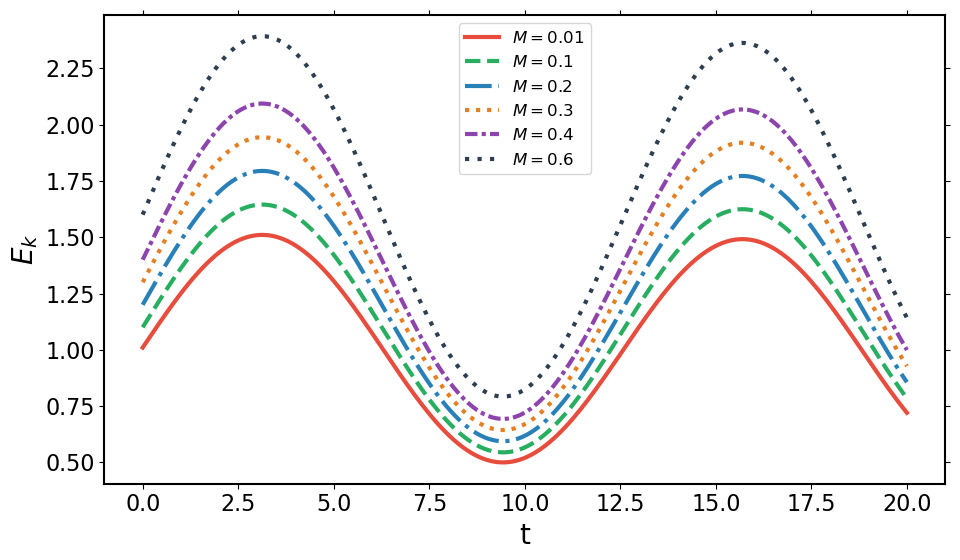

In [1]:
#!/usr/bin/env python3
"""
Plot kinetic energy $E_k$ time series for multiple M values.

Public version with synthetic data for demonstration.

Author: [Your Name]
License: MIT
"""

import numpy as np
import matplotlib.pyplot as plt
from cycler import cycler
from pathlib import Path

# -----------------------------
# Synthetic data generator
# -----------------------------
def load_ek(eta, M, tmax=20, nt=200):
    t = np.linspace(0, tmax, nt)
    Ek = (1 + 0.5*np.sin(0.5*t)) * np.exp(-eta*t) * (1 + M)
    return t, Ek

# -----------------------------
# Main plotting routine
# -----------------------------
def main():
    # Custom style
    colors = cycler('color', [
        '#E74C3C', '#27AE60', '#2980B9', '#E67E22',
        '#8E44AD', '#2C3E50', '#1ABC9C', '#95A5A6'
    ])
    plt.rcdefaults()
    plt.style.use('default')
    plt.rc('axes', edgecolor='black', axisbelow=True, grid=False, prop_cycle=colors)
    plt.rcParams.update({
        'font.size': 20,
        'figure.autolayout': True,
        "axes.spines.top": True,
        "axes.spines.right": True,
        "axes.spines.left": True,
        "axes.spines.bottom": True,
        "xtick.top": True,
        "ytick.right": True,
        "axes.grid": False
    })

    linestyles = ['-', '--', '-.', ':', (0, (3,1,1,1)), (0, (1,2))]

    fig, ax = plt.subplots(figsize=(10,6))
    ax.set_facecolor('white')

    eta = 0.001
    Mvals = [0.01, 0.1, 0.2, 0.3, 0.4, 0.6]

    # Plot curves
    for M, ls in zip(Mvals, linestyles):
        t, Ek = load_ek(eta, M)
        ax.plot(t, Ek, linestyle=ls, label=f'$M={M}$', lw=3)

    ax.set_xlabel('t')
    ax.set_ylabel('$E_k$')
    ax.legend(fontsize=12)
    ax.tick_params(axis='both', labelsize=16)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.5)
        spine.set_color('black')

    fig.tight_layout()

    # Save figure
    outdir = Path("figures")
    outdir.mkdir(exist_ok=True)
    fig.savefig(outdir / "ek_time_series.png", dpi=300)
    plt.show()

if __name__ == "__main__":
    main()
